**Dataset Overview**

The Liberty Mutual Fire Peril Loss Cost dataset contains 105,450 commercial insurance records and 302 variables. In addition, there are 292 numerical variables and 10 categorical variables and 1 is an identifier. The response variable is target and this represents the fire-peril loss cost.

The dataset is representative of a typical commercial insurance dataset because there is extreme skewness, heavy tails and a large number of zeros. This makes it a strong candidate for GLMs (Tweedie/Gamma) and tree-based ensemble models.

In [8]:
# ======================================================
# CIND820 - Keystone Project
# Data Analysis and Visualization: Fire Peril Loss Cost (Liberty Mutual Insurance)
# Author: Debra Allen 
# ======================================================

# Call Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

In [11]:
# ======================================================
# Descriptive Statistics
# ======================================================

def find_repo_root(start: Path | None = None) -> Path:
    """Find the root of the git repository."""
    if start is None:
        start = Path.cwd()
    start = start.resolve()
    
    markers = [".git", "pyproject.toml", "requirements.txt"]
    for p in [start, *start.parents]:
        if any((p / m).exists() for m in markers):
            return p
    raise FileNotFoundError("Could not find repo root. Run notebook from inside the repo.")

REPO_ROOT = find_repo_root()
DATA_PATH = REPO_ROOT /"liberty_train.csv"
print("Repo Root:", REPO_ROOT)
print("Data Path:", DATA_PATH)

# Read the dataset
data = pd.read_csv(DATA_PATH, low_memory=False)

# Display the shape of the dataset
print("\nDataset Shape:", data.shape)

# Display the first few rows of the dataset
print("\nFirst few rows of the dataset:")
data.head()

Repo Root: C:\Users\uni_f\Downloads\LaTex\TMU-CIND820
Data Path: C:\Users\uni_f\Downloads\LaTex\TMU-CIND820\liberty_train.csv

Dataset Shape: (452061, 302)

First few rows of the dataset:


,id,target,var1,var2,var3,var4,var5,var6,var7,var8,...,weatherVar227,weatherVar228,weatherVar229,weatherVar230,weatherVar231,weatherVar232,weatherVar233,weatherVar234,weatherVar235,weatherVar236
0,1,0.0,Z,Z,Z,N1,Z,Z,3,1,...,0.170351,0.0,0.00000,0.000000,1.117353,1.215303,0.112556,2.355737,0.404655,0.138667
1,2,0.0,Z,Z,Z,C1,Z,Z,3,2,...,0.266173,0.0,27.50823,0.000000,3.828979,1.036739,0.033052,0.856632,0.231232,0.742199
2,3,0.0,3,Z,4,J3,B,B,2,4,...,0.979517,0.0,0.00000,0.456134,0.098790,1.076535,0.566352,0.696013,0.693695,0.070654
3,4,0.0,3,Z,4,H1,B,Z,3,4,...,0.308761,0.0,0.00000,4.349042,0.401975,0.340631,0.290147,0.000000,0.000000,0.090332
4,5,0.0,Z,Z,Z,H1,Z,Z,2,4,...,2.171972,0.0,0.00000,0.514990,0.516095,1.016120,1.313732,1.338487,2.948202,0.816485


In [12]:
# Reduce the size of the Train dataset to 25 % as the memory is being fully exhausted
# The rows are selected randomly

train = data.sample(frac = .25, replace = False)

In [13]:
# Display basic structure of the dataset
print("\nDataset Info:")
train.info()

# Display the shape of the reduced dataset
print("\nDataset Shape:", train.shape)


Dataset Info:
<class 'pandas.DataFrame'>
Index: 113015 entries, 128744 to 225833
Columns: 302 entries, id to weatherVar236
dtypes: float64(291), int64(1), str(10)
memory usage: 261.3 MB

Dataset Shape: (113015, 302)


In [28]:
# Display summary statistics of the dataset
print("\nSummary Statistics:")
train.describe()


Summary Statistics:


,id,target,var10,var11,var12,var13,var14,var15,var16,var17,...,weatherVar227,weatherVar228,weatherVar229,weatherVar230,weatherVar231,weatherVar232,weatherVar233,weatherVar234,weatherVar235,weatherVar236
count,113015.000000,113015.000000,113015.000000,113015.000000,24285.000000,113015.000000,40410.000000,88368.000000,22634.000000,113015.000000,...,108218.000000,108218.000000,108218.000000,108218.000000,108218.000000,108218.000000,108218.000000,108218.000000,108218.000000,108218.000000
mean,452059.193868,0.006180,4.128454,1316.001939,3.098764,1.304795,0.222034,31.163328,73.254705,68.561699,...,0.948338,0.792867,1.012005,0.970197,1.008444,1.012088,0.895103,1.072779,0.993245,1.045110
std,260785.668579,0.195755,0.311165,1084.700057,0.290032,0.814208,0.427496,25.511297,43.384470,37.321490,...,0.733207,26.708848,3.807272,1.890621,3.381126,0.183468,1.108364,0.908525,1.373227,4.688720
min,2.000000,0.000000,3.742477,500.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.010647,0.000000,0.000000,0.000000,0.000000,0.000000,0.001047,0.000000,0.000000,0.000000
25%,227064.000000,0.000000,3.898949,681.909085,2.936187,0.832555,0.000000,13.000000,8.000000,49.721090,...,0.415230,0.000000,0.000000,0.000000,0.069835,0.906219,0.246716,0.374776,0.231232,0.030111
50%,452745.000000,0.000000,4.039930,939.414711,3.096498,1.394959,0.000000,26.000000,100.000000,85.921889,...,0.777225,0.000000,0.000000,0.344728,0.200987,1.060452,0.746745,0.856632,0.578079,0.120323
75%,678003.500000,0.000000,4.314082,1500.000000,3.273289,1.939381,0.000000,41.000000,100.000000,100.000000,...,1.288277,0.000000,0.000000,1.366301,0.676203,1.134062,1.230880,1.552645,1.213965,0.397512
max,902755.000000,18.985234,5.677710,14104.377710,3.961367,2.894981,2.168059,440.500000,100.000000,100.000000,...,3.641247,3778.103919,171.926438,55.553810,137.327164,1.546449,50.053757,5.353948,8.093103,100.087491


In [29]:
# Display the data types of the columns in the dataset
print("\nData Types of Columns:")
train.dtypes


Data Types of Columns:


id                 int64
target           float64
var1                 str
var2                 str
var3                 str
                  ...   
weatherVar232    float64
weatherVar233    float64
weatherVar234    float64
weatherVar235    float64
weatherVar236    float64
Length: 302, dtype: object

In [107]:
# Compute mean, median, standard deviation, max, min and zero-rate 
# of the target variable only in both the reduced and full datasets

if 'target' in train.columns:
    print('Mean Loss Cost - Reduced Dataset:', train['target'].mean())
    print('Median - Reduced Dataset:', train['target'].median())
    print('Standard Deviation - Reduced Dataset:', train['target'].std())
    print('Max - Reduced Dataset:', train['target'].max())
    print('Min - Reduced Dataset:', train['target'].min())
    perc_zero = (train['target'] == 0).mean() * 100
    print('Zero-rate - Reduced Dataset: {:.4f}%'.format(perc_zero))
else:
    print('train target column not found')

if 'target' in data.columns:
    print('\nMean Loss Cost - Full Dataset:', data['target'].mean())
    print('Median - Full Dataset:', data['target'].median())
    print('Standard Deviation - Full Dataset:', data['target'].std())
    print('Max - Full Dataset:', data['target'].max())
    print('Min - Full Dataset:', data['target'].min())
    perc_zero = (data['target'] == 0).mean() * 100
    print('Zero-rate - Full Dataset: {:.4f}%'.format(perc_zero))
else:
    print('data target column not found')

Mean Loss Cost - Reduced Dataset: 0.006179510060363668
Median - Reduced Dataset: 0.0
Standard Deviation - Reduced Dataset: 0.19575471435434177
Max - Reduced Dataset: 18.98523446
Min - Reduced Dataset: 0.0
Zero-rate - Reduced Dataset: 99.7540%

Mean Loss Cost - Full Dataset: 0.007234069647007815
Median - Full Dataset: 0.0
Standard Deviation - Full Dataset: 0.21968841298549557
Max - Full Dataset: 25.92013792
Min - Full Dataset: 0.0
Zero-rate - Full Dataset: 99.7372%


In [44]:
# Separate Variable types
categorical_cols = train.select_dtypes(include=['object']).columns
numerical_cols = train.select_dtypes(include=['number']).columns

print("\nCategorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

# Display the number of categorical and numerical columns
print("\nNumber of Categorical Columns:", len(categorical_cols))
print("Number of Numerical Columns:", len(numerical_cols))


Categorical Columns: Index(['var1', 'var2', 'var3', 'var4', 'var5', 'var6', 'var7', 'var8', 'var9',
       'dummy'],
      dtype='str')
Numerical Columns: Index(['id', 'target', 'var10', 'var11', 'var12', 'var13', 'var14', 'var15',
       'var16', 'var17',
       ...
       'weatherVar227', 'weatherVar228', 'weatherVar229', 'weatherVar230',
       'weatherVar231', 'weatherVar232', 'weatherVar233', 'weatherVar234',
       'weatherVar235', 'weatherVar236'],
      dtype='str', length=292)

Number of Categorical Columns: 10
Number of Numerical Columns: 292


C:\Users\uni_f\AppData\Local\Temp\ipykernel_35444\4156532869.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train.select_dtypes(include=['object']).columns


In [51]:
# Display summary statistics for numerical columns
describe_numerical = train[numerical_cols].describe().T
print("\nSummary Statistics for Numerical Columns:")
print(describe_numerical)

# Determine skewness and kurtosis for the numerical columns
skewness_train = train[numerical_cols].skew()
kurtosis_train = train[numerical_cols].kurtosis()

print("\nSkewness for Numerical Columns:")
print(skewness_train)

print("\nKurtosis for Numerical Columns:")
print(kurtosis_train)


Summary Statistics for Numerical Columns:
                  count           mean            std         min  \
id             113015.0  452059.193868  260785.668579    2.000000   
target         113015.0       0.006180       0.195755    0.000000   
var10          113015.0       4.128454       0.311165    3.742477   
var11          113015.0    1316.001939    1084.700057  500.000000   
var12           24285.0       3.098764       0.290032    0.000000   
...                 ...            ...            ...         ...   
weatherVar232  108218.0       1.012088       0.183468    0.000000   
weatherVar233  108218.0       0.895103       1.108364    0.001047   
weatherVar234  108218.0       1.072779       0.908525    0.000000   
weatherVar235  108218.0       0.993245       1.373227    0.000000   
weatherVar236  108218.0       1.045110       4.688720    0.000000   

                         25%            50%            75%            max  
id             227064.000000  452745.000000  678003.

*The 'target' variable is dominated by zero values:*

Mean loss cost: approx 0.007
Median: 0
Maximum observed loss cost: 25.9
Approximately 99.7% of observations have zero loss cost
Skewness: approx 46
Kurtosis: > 2300

This confirms that the most policies have no losses at all, but when a loss occurs it can sometimes be very large. This means that the loss cost must be modeled using a distribution that combines a spike at zero with a separate distribution that allows for rare, extreme losses.

**Descriptive Statistics Interpretation**

The descriptive statistics indicates that the fire-peril loss cost is extremely sparse and heavily right-skewed. The target variable has a median of 0 and more than 99% of the observations report no losses. The skewness and kurtosis values are very high and this confirms that there are rare, but large losses. 

Raw histogram of target variable shows extreme spike at zero.


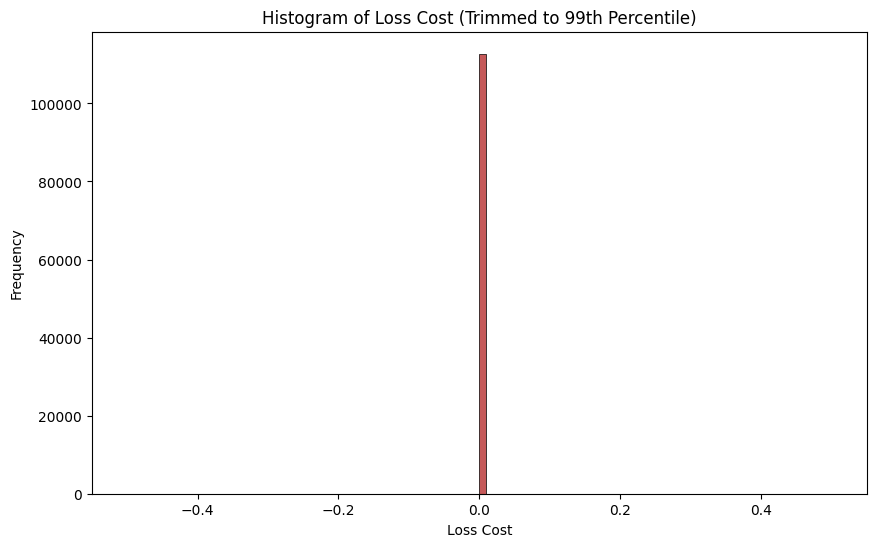

In [65]:
# ======================================================
# Visualization of the Target Variable
# ======================================================

# Plot histogram of target variable, trimmed to 99th percentile to remove extreme tail
print("Raw histogram of target variable shows extreme spike at zero.")

# Plot histogram
plt.figure(figsize=(10, 6))
sns.histplot(train['target'][train['target'] <= train['target'].quantile(0.99)], bins=100, color='firebrick')
plt.title('Histogram of Loss Cost (Trimmed to 99th Percentile)')
plt.xlabel('Loss Cost')
plt.ylabel('Frequency')
plt.show()

Log-transformed histogram of loss cost (positive losses only) shows a long right tail.


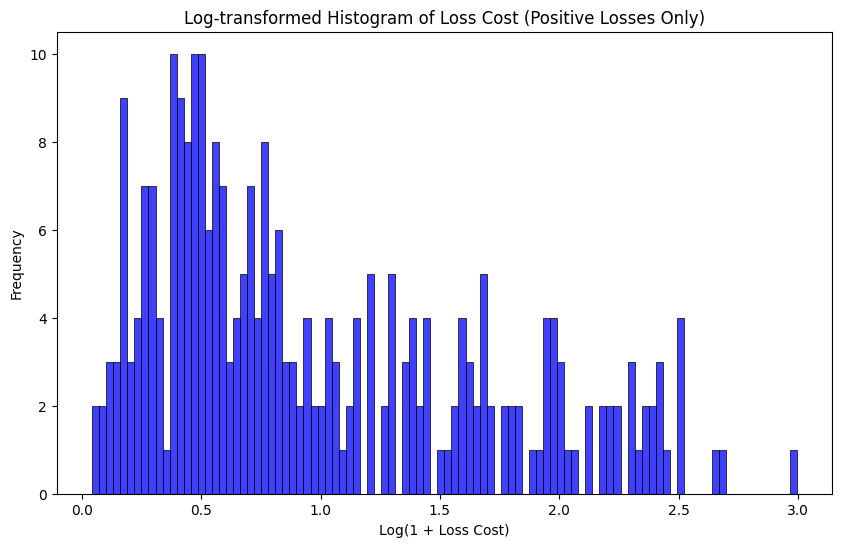

In [67]:
# Log-transformed histogram of target variable - positive losses only
print("Log-transformed histogram of loss cost (positive losses only) shows a long right tail.")

# Determine positive losses only
positive_losses = train.loc[train['target'] > 0, 'target']

# Plot histogram
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(positive_losses), bins=100, color='blue')
plt.title('Log-transformed Histogram of Loss Cost (Positive Losses Only)')
plt.xlabel('Log(1 + Loss Cost)')
plt.ylabel('Frequency')
plt.show()


Missing Values Count for Each Column:
var16        90381
var12        88730
var14        72605
crimeVar7    29244
crimeVar2    28524
             ...  
var3             0
var2             0
var1             0
target           0
id               0
Length: 302, dtype: int64

Top 20 Variables with the Most Missing Values:
var16            90381
var12            88730
var14            72605
crimeVar7        29244
crimeVar2        28524
crimeVar4        28177
crimeVar5        27605
crimeVar9        27457
crimeVar6        27457
crimeVar3        27457
crimeVar8        27457
crimeVar1        27457
var15            24647
weatherVar224     8135
weatherVar223     8135
weatherVar213     8135
weatherVar226     8135
weatherVar212     8135
weatherVar211     8135
weatherVar210     8135
dtype: int64


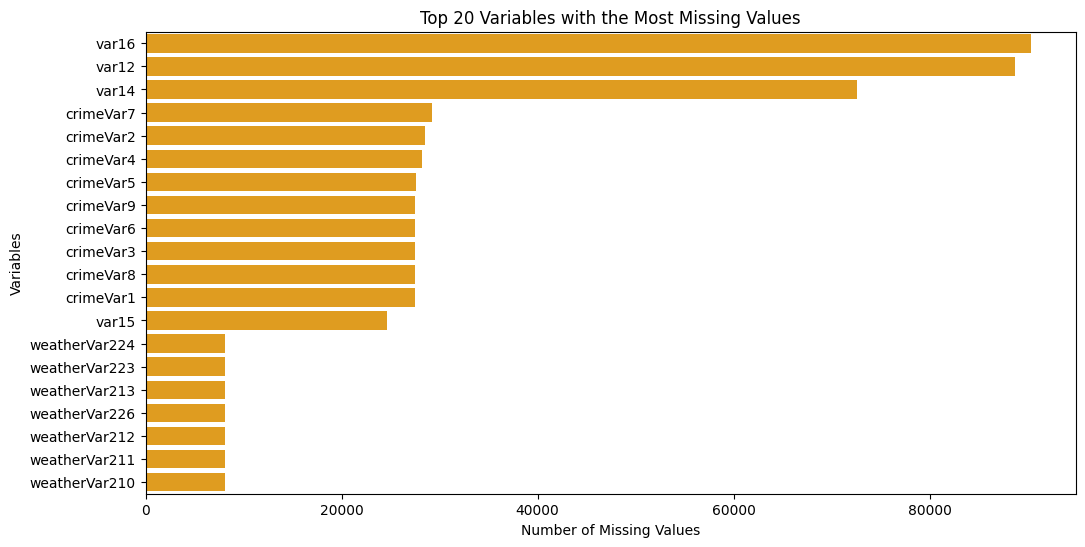

In [75]:
# ======================================================
# Missing Data Analysis
# ======================================================

# Count number of missing values
missing_counts = train.isnull().sum().sort_values(ascending=False)
print("\nMissing Values Count for Each Column:")
print(missing_counts)

# Top 20 variables with the most missing values
print("\nTop 20 Variables with the Most Missing Values:")
print(missing_counts.head(20))

# Bar plot of missing values for top 20 variables
plt.figure(figsize=(12, 6))
sns.barplot(y=missing_counts.head(20).index, x=missing_counts.head(20).values, color='orange')
plt.title('Top 20 Variables with the Most Missing Values')
plt.ylabel('Variables')
plt.xlabel('Number of Missing Values')
plt.show()


Correlation Matrix for Numerical Columns:
                     id    target     var10     var11     var12     var13  \
id             1.000000 -0.002277  0.006346 -0.000207  0.002150  0.003813   
target        -0.002277  1.000000 -0.010308 -0.000270  0.012111 -0.012117   
var10          0.006346 -0.010308  1.000000  0.233305 -0.061589  0.665386   
var11         -0.000207 -0.000270  0.233305  1.000000  0.556335  0.127221   
var12          0.002150  0.012111 -0.061589  0.556335  1.000000 -0.297754   
...                 ...       ...       ...       ...       ...       ...   
weatherVar232 -0.002381 -0.000622 -0.106972 -0.022943  0.002623 -0.123697   
weatherVar233  0.000011  0.002709  0.050345  0.042965 -0.001447  0.044179   
weatherVar234 -0.004511  0.001798 -0.041361 -0.028170 -0.003869 -0.068925   
weatherVar235  0.002953  0.004523  0.029585  0.005231  0.015805 -0.000918   
weatherVar236 -0.000761  0.000513  0.007052 -0.003522  0.023491  0.002747   

                  var14     var1

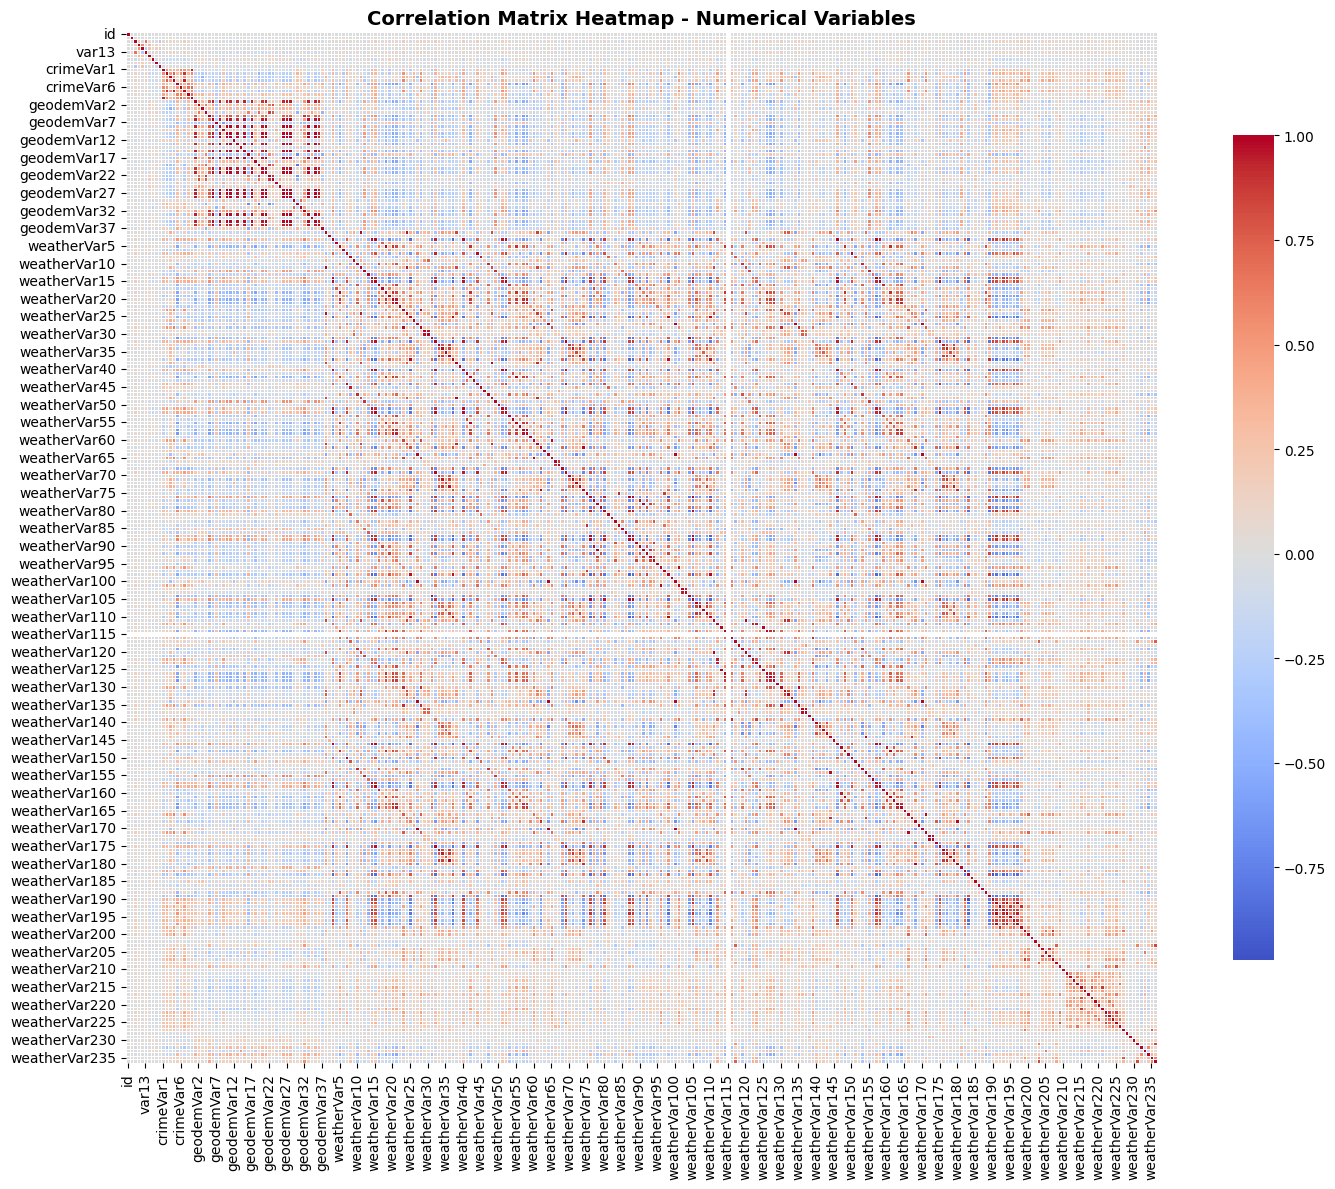


Correlation with Target Variable (sorted):
target           1.000000
weatherVar118    0.012933
var12            0.012111
crimeVar5        0.010462
weatherVar226    0.010043
                   ...   
geodemVar34     -0.006860
var10           -0.010308
var13           -0.012117
var16           -0.019780
weatherVar115         NaN
Name: target, Length: 292, dtype: float64


C:\Users\uni_f\AppData\Local\Temp\ipykernel_35444\1109745122.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='coolwarm')


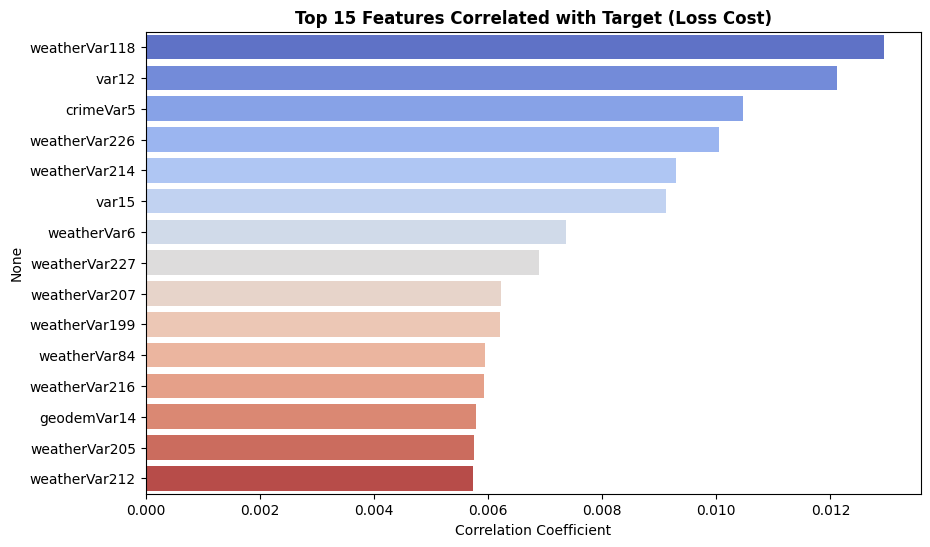

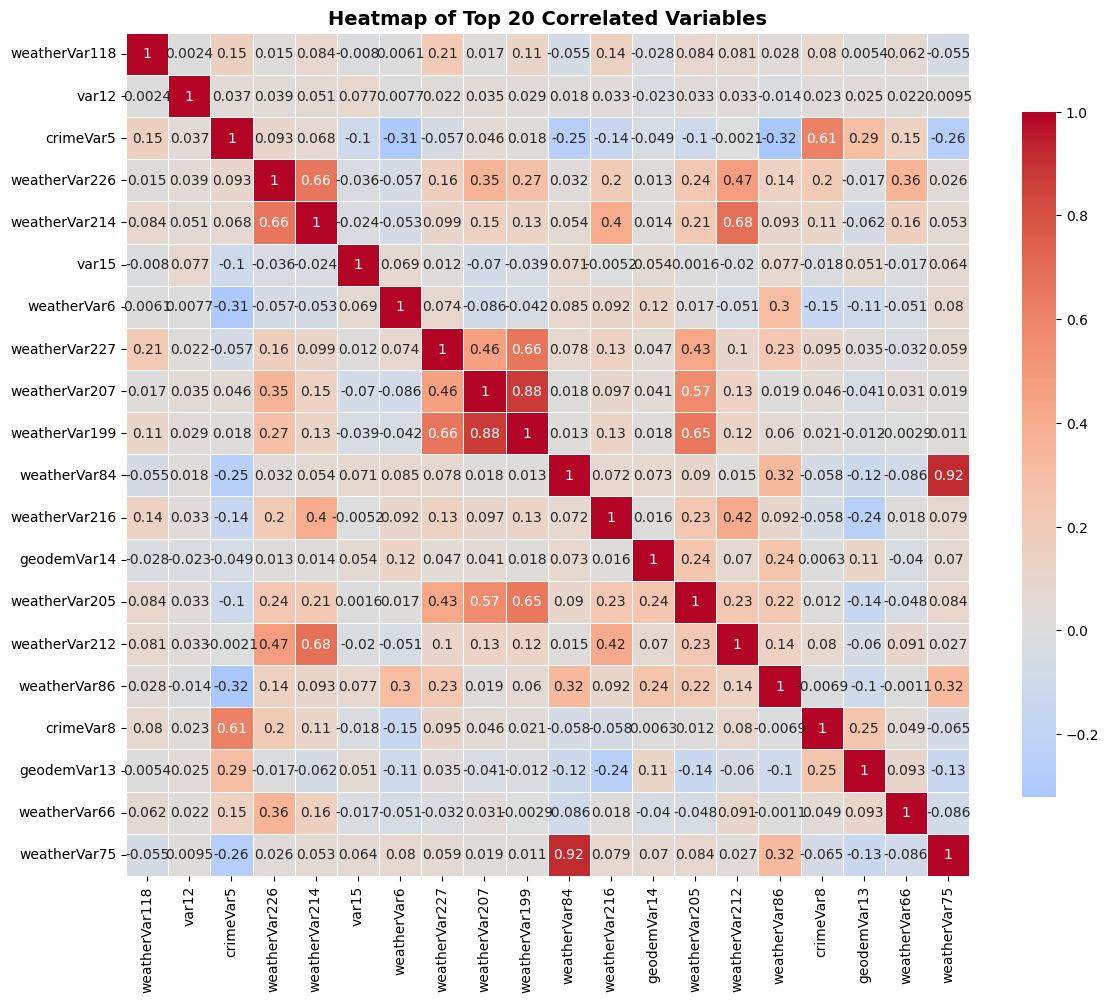

In [80]:
# =======================================================
# Correlation Analysis
# =======================================================

# Compute correlation matrix for loss cost and numerical variables
correlation_matrix = train[numerical_cols].corr()

print("\nCorrelation Matrix for Numerical Columns:")
print(correlation_matrix)

# Visualize correlation matrix with heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix Heatmap - Numerical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation with target variable
if 'target' in train.columns:
    target_corr = correlation_matrix['target'].sort_values(ascending=False)
    print("\nCorrelation with Target Variable (sorted):")
    print(target_corr)
    
    # Plot top 15 features correlated with target
    plt.figure(figsize=(10, 6))
    top_corr = target_corr[1:16]  # Exclude target itself
    sns.barplot(x=top_corr.values, y=top_corr.index, palette='coolwarm')
    plt.title('Top 15 Features Correlated with Target (Loss Cost)', fontsize=12, fontweight='bold')
    plt.xlabel('Correlation Coefficient')
    plt.show()

# Heatmap of top 20 correlated variables
top_corr_vars = target_corr[1:21].index  # Exclude target itself
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix.loc[top_corr_vars, top_corr_vars], annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Heatmap of Top 20 Correlated Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


The Pearson correlations between predictors and the target variable are uniformly weak. This shows that claims are rare.

The top correlated variables weather, crime and geodemographic indicators.


Top 3 Features Most Correlated with Target Variable:
Index(['weatherVar118', 'var12', 'crimeVar5'], dtype='str')


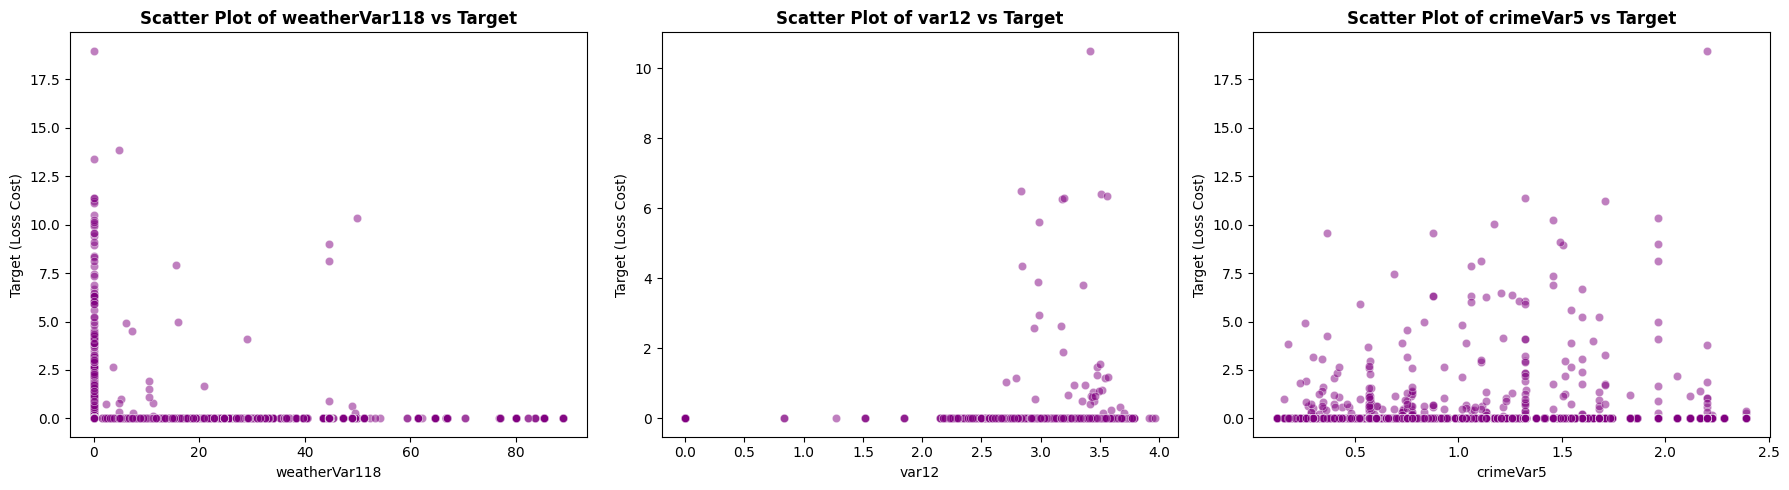

In [81]:
# =======================================================
# Scatter Plots of Top Correlated Variables with Target
# =======================================================

# Top 3 features most correlated with target variable
top3 = target_corr[1:4].index  # Exclude target itself
print("\nTop 3 Features Most Correlated with Target Variable:")
print(top3)

# Scatter plots of top 3 features with target variable
plt.figure(figsize=(18, 5))
for i, feature in enumerate(top3):
    plt.subplot(1, 3, i+1)
    sns.scatterplot(x=train[feature], y=train['target'], alpha=0.5, color='purple')
    plt.title(f'Scatter Plot of {feature} vs Target', fontsize=12, fontweight='bold')
    plt.xlabel(feature)
    plt.ylabel('Target (Loss Cost)')
plt.tight_layout()
plt.show()


The scatter plots of the top 3 correlated predictors confirm that the relationships are non-linear.

**Insights on Correlation between Predictors and Target Variable (Loss Cost)**

The fire-peril lost cost data has very many zeros, with nearly all observations equal to zero and a small number of extreme positive losses. The correlations between the predictors and loss cost are uniformly weak. The suggests that linear effects alone are not sufficient. This means that Tweedie GLMs and gradient boosting methods will have to be used.

In [99]:
# =======================================================
# Data Preparation for Modeling: Fire Peril Loss Cost
# =======================================================

# Import necessary libraries for data preparation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [85]:
# Use a smaller sample for modeling to avoid memory issues
SAMPLE_URL = "https://media.githubusercontent.com/media/uni-Deb7943/TMU-CIND820/refs/heads/main/liberty_train_subset.csv?token=CATLW7TMA2QGA2QVVA6L3STJYXAXO"
model_data = pd.read_csv(SAMPLE_URL, low_memory=False)

model_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 113015 entries, 0 to 113014
Columns: 302 entries, id to weatherVar236
dtypes: float64(291), int64(1), str(10)
memory usage: 260.4 MB


In [87]:
# Verify that all categorical variables are strings
for col in model_data.select_dtypes(include=['object']).columns:
    model_data[col] = model_data[col].astype(str)

print("\nAll categorical variables have been converted to strings.")

print("\nDataset Shape:", model_data.shape)


All categorical variables have been converted to strings.

Dataset Shape: (113015, 302)


C:\Users\uni_f\AppData\Local\Temp\ipykernel_35444\4162061741.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in model_data.select_dtypes(include=['object']).columns:


In [89]:
# Define target variable
target = 'target'

# Feature matrix and response
X = model_data.drop(columns=[target])
y = model_data[target]

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("\nCategorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

# Display the number of categorical and numerical columns
print("\nNumber of Categorical Columns:", len(categorical_cols))
print("Number of Numerical Columns:", len(numerical_cols))


Categorical Columns: ['var1', 'var2', 'var3', 'var4', 'var5', 'var6', 'var7', 'var8', 'var9', 'dummy']
Numerical Columns: ['id', 'var10', 'var11', 'var12', 'var13', 'var14', 'var15', 'var16', 'var17', 'crimeVar1', 'crimeVar2', 'crimeVar3', 'crimeVar4', 'crimeVar5', 'crimeVar6', 'crimeVar7', 'crimeVar8', 'crimeVar9', 'geodemVar1', 'geodemVar2', 'geodemVar3', 'geodemVar4', 'geodemVar5', 'geodemVar6', 'geodemVar7', 'geodemVar8', 'geodemVar9', 'geodemVar10', 'geodemVar11', 'geodemVar12', 'geodemVar13', 'geodemVar14', 'geodemVar15', 'geodemVar16', 'geodemVar17', 'geodemVar18', 'geodemVar19', 'geodemVar20', 'geodemVar21', 'geodemVar22', 'geodemVar23', 'geodemVar24', 'geodemVar25', 'geodemVar26', 'geodemVar27', 'geodemVar28', 'geodemVar29', 'geodemVar30', 'geodemVar31', 'geodemVar32', 'geodemVar33', 'geodemVar34', 'geodemVar35', 'geodemVar36', 'geodemVar37', 'weatherVar1', 'weatherVar2', 'weatherVar3', 'weatherVar4', 'weatherVar5', 'weatherVar6', 'weatherVar7', 'weatherVar8', 'weatherVar9', 

C:\Users\uni_f\AppData\Local\Temp\ipykernel_35444\1606720166.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


In [103]:
# =======================================================
# Handle Missing Values and Encode Categorical Variables
# =======================================================

# Categorical columns summary
print("\nSummary Statistics for Categorical Columns:")
print(model_data[categorical_cols].describe().T)
print("\nUnique Value Counts for Categorical Columns:")
for col in categorical_cols:
    print(f"\nUnique value counts for {col}:")
    print(model_data[col].value_counts())

# Percentage of missing values in each column
missing_values = model_data.isnull().mean() * 100
print(f"\nPercentage of Missing Values in Each Column:")
print(missing_values)

# median for numerical
num_imputer = SimpleImputer(strategy='median')
model_data[numerical_cols] = num_imputer.fit_transform(model_data[numerical_cols])

# most frequent for categorical
cat_imputer = SimpleImputer(strategy='most_frequent')
model_data[categorical_cols] = cat_imputer.fit_transform(model_data[categorical_cols])

# verify that missing values are handled
print("\nMissing values after imputation:")
print(model_data.isnull().sum().sort_values(ascending=False).head(20))

# Combine imputation and encoding in a pipeline
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
],
remainder='drop')


Summary Statistics for Categorical Columns:
        count unique top    freq
var1   113015      6   Z   84432
var2   113015      4   Z  111916
var3   113015      7   Z   98718
var4   113015     43  H1   29105
var5   113015      7   Z  103970
var6   113015      4   Z  106238
var7   113015      9   3   30413
var8   113015      7   2   30450
var9   113015      3   A   73564
dummy  113015      2   A   82166

Unique Value Counts for Categorical Columns:

Unique value counts for var1:
var1
Z    84432
3    14384
2     8324
4     5344
1      518
5       13
Name: count, dtype: int64

Unique value counts for var2:
var2
Z    111916
B       610
C       415
A        74
Name: count, dtype: int64

Unique value counts for var3:
var3
Z    98718
3     5807
4     5035
2     1594
6      843
5      711
1      307
Name: count, dtype: int64

Unique value counts for var4:
var4
H1    29105
D3    13126
M1    10737
O2     8747
Z      5042
D1     4595
G1     4207
E3     3846
C1     2925
I1     2435
A1     2054
N

In [104]:
# =======================================================
# Train-Test Split
# =======================================================

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTraining observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])


Training observations: 90412
Testing observations: 22603


In [105]:
# =======================================================
# Data Preprocessing Pipeline
# =======================================================

# Fit prepocessing pipeline on training data and transform both training and testing data
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print("\nData preprocessing pipeline has been applied to training and testing data.")

print("\nShape of preprocessed training data:", X_train_prepared.shape)
print("Shape of preprocessed testing data:", X_test_prepared.shape)


Data preprocessing pipeline has been applied to training and testing data.

Shape of preprocessed training data: (90412, 383)
Shape of preprocessed testing data: (22603, 383)


In [106]:
# =======================================================
# Subsample for Modeling Efficiency
# =======================================================

# To further reduce memory usage, take a random subsample of the preprocessed training data for modeling.
sample_size = 5000  # Adjust this number based on memory constraints

if X_train_prepared.shape[0] > sample_size:
    idx = np.random.choice(X_train_prepared.shape[0], sample_size, replace=False)
    X_train_sample = X_train_prepared[idx]
    y_train_sample = y_train.iloc[idx]
    print(f"\nSubsampled {sample_size} observations for modeling.")
else:
    X_train_sample = X_train_prepared
    y_train_sample = y_train
    print("\nTraining data is small enough to use without subsampling.")


Subsampled 5000 observations for modeling.
